## Introduction

This notebook shows how to use the Qiskit Aer `noise` module to automatically generate a basic noise model for an IBMQ hardware device, and use this model to do noisy simulations of QuantumCircuits to study the effects of errors which occur on real devices.

Note, that these automatic models are only an approximation of the real errors that occur on actual devices, due to the fact that they must be build from a limited set of input parameters related to average error rates on gates. The study of quantum errors on real devices is an active area of research and we discuss the Qiskit Aer tools for configuring more detailed noise models in another notebook.

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

## Device Backend Noise Model

The Qiskit Aer device noise model automatically generates a simplified noise model for a real device. This model is generated using the calibration information reported in the properties of a device and takes into account

- The gate_error probability of each basis gate on each qubit.
- The gate_length of each basis gate on each qubit.
- The relaxation time constants of each qubit.
- The readout error probability of each qubit.

### Fake Provider Backends
We will use real noise data for an IBM Quantum device using the data stored in Qiskit Terra.

In [2]:
from qiskit_ibm_runtime.fake_provider import FakeVigoV2
device_backend = FakeVigoV2()

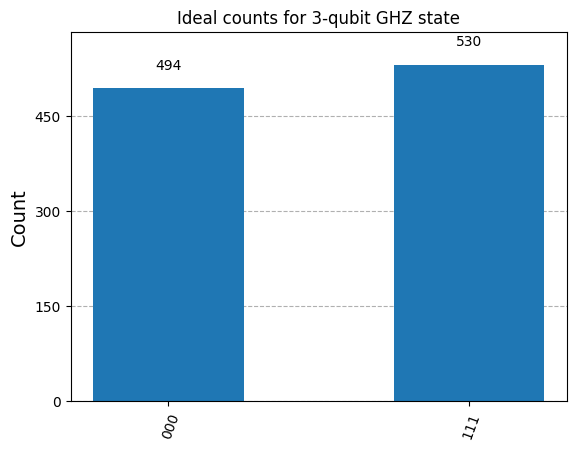

In [3]:
# Construct quantum circuit
circ = QuantumCircuit(3, 3)
circ.h(0)
circ.cx(0, 1)
circ.cx(1, 2)
circ.measure([0, 1, 2], [0, 1, 2])

sim_ideal = AerSimulator()

# Execute and get counts
result = sim_ideal.run(transpile(circ, sim_ideal)).result()
counts = result.get_counts(0)
plot_histogram(counts, title='Ideal counts for 3-qubit GHZ state')

In [5]:
sim_vigo = AerSimulator.from_backend(device_backend)

By storing the device properties in vigo_simulator, we ensure that the appropriate basis gates and coupling map are used when compiling circuits for simulation, thereby most closely mimicking the gates that will be executed on a real device. In addition vigo_simulator contains an approximate noise model consisting of:

- Single-qubit gate errors consisting of a single qubit depolarizing error followed by a single qubit thermal relaxation error.
- Two-qubit gate errors consisting of a two-qubit depolarizing error followed by single-qubit thermal relaxation errors on both qubits in the gate.
- Single-qubit readout errors on the classical bit value obtained from measurements on individual qubits.


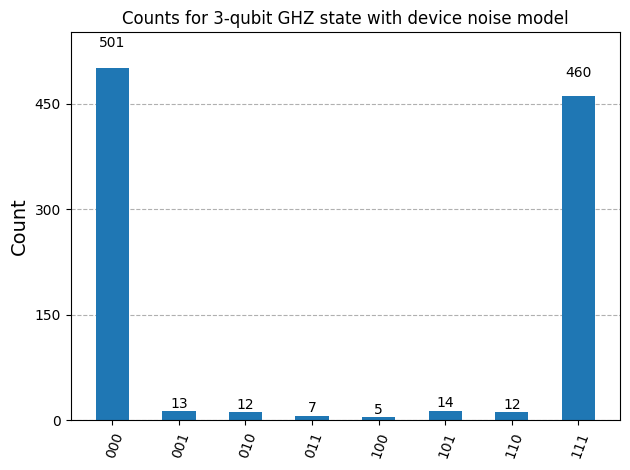

In [ ]:
# Transpile the circuit for the noisy basis gates
tcirc = transpile(circ, sim_vigo)

# Execute noisy simulation and get counts
result_noise = sim_vigo.run(tcirc).result()
counts_noise = result_noise.get_counts(0)
plot_histogram(counts_noise,
               title="Counts for 3-qubit GHZ state with device noise model")

In [ ]:
tcirc.draw()

global phase: π/4
                                     ┌───┐        ┌─┐   
q_1 -> 1 ────────────────────────────┤ X ├──■─────┤M├───
         ┌─────────┐┌────┐┌─────────┐└─┬─┘  │  ┌─┐└╥┘   
q_0 -> 2 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──■────┼──┤M├─╫────
         └─────────┘└────┘└─────────┘     ┌─┴─┐└╥┘ ║ ┌─┐
q_2 -> 3 ─────────────────────────────────┤ X ├─╫──╫─┤M├
                                          └───┘ ║  ║ └╥┘
    c: 3/═══════════════════════════════════════╩══╩══╩═
                                                0  1  2

In [ ]:
device_backend.instructions

[(Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (0,)),
 (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (1,)),
 (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (2,)),
 (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (3,)),
 (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (4,)),
 (Delay(duration=t[unit=dt]), (0,)),
 (Delay(duration=t[unit=dt]), (1,)),
 (Delay(duration=t[unit=dt]), (2,)),
 (Delay(duration=t[unit=dt]), (3,)),
 (Delay(duration=t[unit=dt]), (4,)),
 (Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]), (0,)),
 (Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]), (1,)),
 (Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]), (2,)),
 (Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]), (3,)),
 (Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]), (4,)),
 (Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
  (